# Settings

In [1]:
alpha = 0.05 

In [2]:
def underline(txt: str) -> str:
    """Return *txt* underlined for terminals that support ANSI codes."""
    return f"\033[4m{txt}\033[0m"

def bold(txt: str) -> str:
    """Return *txt* wrapped in the ANSI code for bold (bright) text."""
    return f"\033[1m{txt}\033[0m"

Loading the Study Results into a Dataframe: 

In [3]:
import pandas as pd

from Study import participants
from HelperFunctions.get_data import get_data

df = get_data(participants=participants, task_ids=[i for i in range(1,18)])
df["id"] = df["id"].apply(lambda x: x.replace("task_", "")).astype(int)

Does not know what IF is, question skipped after trying to figure it out skipped
Skipped, too complicated skipped
Skipped, too complicated skipped
Skipped, doesn't know max skipped
Participant found the -1 confusing, skipped skipped
Did not understand, skipped skipped
Participant was overwhelmed, skipped the question skipped
Participant did not understand, skipped  skipped


-> the data frame includes the columns: 
- "id" for the task id
- "participant" for the participants IDs
- the measured "TTU"
- the measured "DOU"
- information about the tasks content 

In [4]:
df_notone = df[df["DOU"] != 1.0]
print(f"❗ Es gibt nur {df_notone.shape[0]} von {df.shape[0]} DOU-Werten, die nicht 1.0 sind.")
print(f"→ Das sind {100 * (1 - df_notone.shape[0] / df.shape[0]):.1f}% exakte 1.0")

❗ Es gibt nur 110 von 357 DOU-Werten, die nicht 1.0 sind.
→ Das sind 69.2% exakte 1.0


# 1) Verteilung prüfen

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats



def check_distribution(df, metric="TTU", group_col="group"):
    groups = df[group_col].unique()
    fig, axes = plt.subplots(len(groups), 2, figsize=(10, 4*len(groups)))

    results = []
    for i, g in enumerate(groups):
        data = df.loc[df[group_col] == g, metric].dropna()

        # Histogramm + KDE
        sns.histplot(data, kde=True, ax=axes[i, 0], color="C0")
        axes[i, 0].set_title(f"{metric} – {g}")

        # QQ‑Plot
        sm.qqplot(data, line="s", ax=axes[i, 1])
        axes[i, 1].set_title(f"QQ‑Plot – {g}")

        # Shapiro‑Wilk
        stat, p = stats.shapiro(data)
        results.append({"group": g, "shapiro_W": stat, "shapiro_p": p})

    plt.tight_layout()
    plt.show()
    return pd.DataFrame(results)


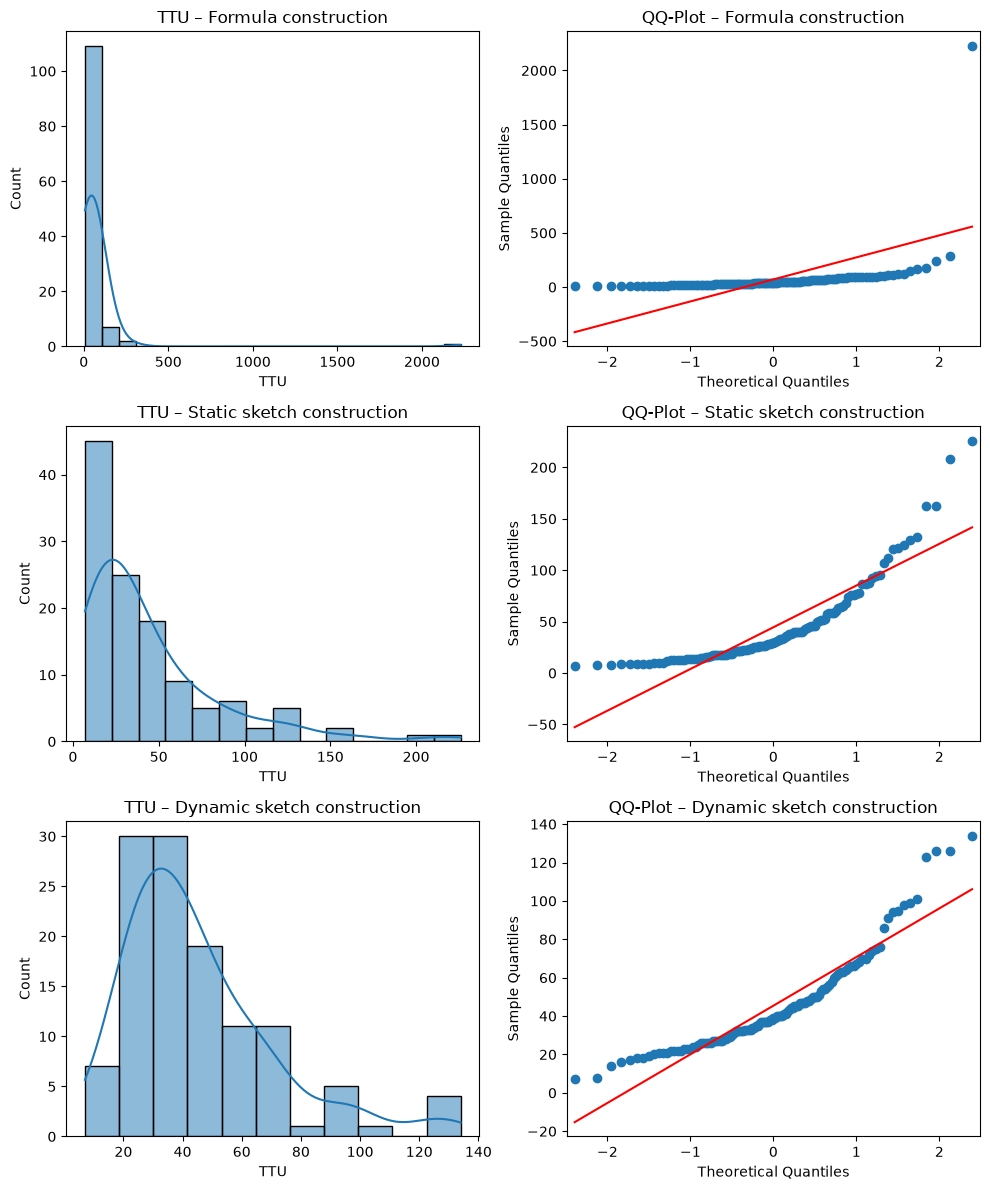


=== Shapiro‑Wilk‑Ergebnisse ===
                         group  shapiro_W     shapiro_p
0         Formula construction   0.185222  9.029329e-23
1   Static sketch construction   0.774329  3.053605e-12
2  Dynamic sketch construction   0.877894  1.880667e-08
['Formula construction', 'Static sketch construction', 'Dynamic sketch construction']


In [6]:
dist_check = check_distribution(df, metric="TTU", group_col="group")
print("\n=== Shapiro‑Wilk‑Ergebnisse ===")
print(dist_check)

non_normal = dist_check.loc[dist_check["shapiro_p"] <= alpha, "group"].tolist()
print(non_normal)

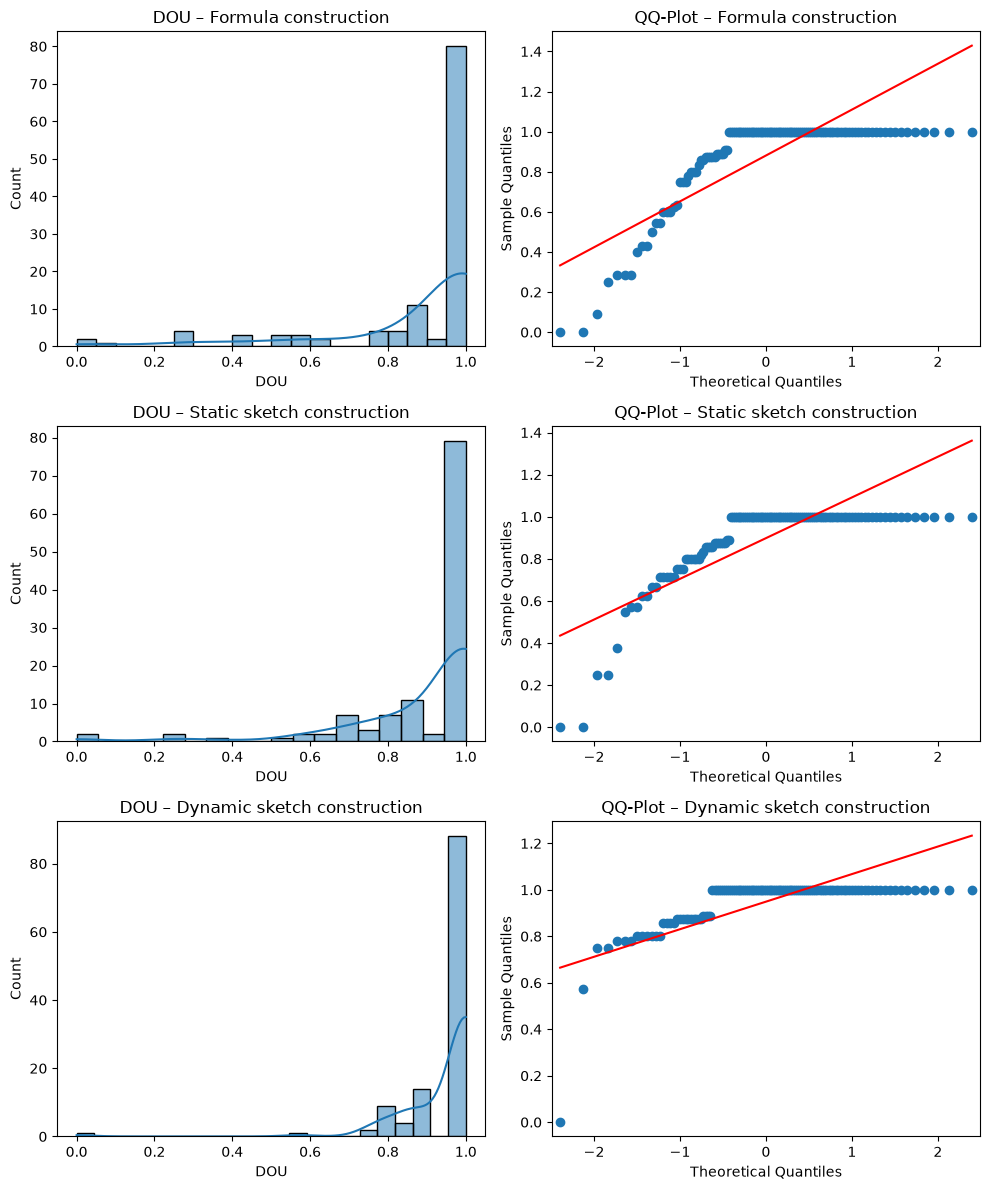


=== Shapiro‑Wilk‑Ergebnisse ===
                         group  shapiro_W     shapiro_p
0         Formula construction   0.593679  1.262942e-16
1   Static sketch construction   0.593346  1.243853e-16
2  Dynamic sketch construction   0.461488  5.482298e-19
['Formula construction', 'Static sketch construction', 'Dynamic sketch construction']


In [7]:
dist_check = check_distribution(df, metric="DOU", group_col="group")
print("\n=== Shapiro‑Wilk‑Ergebnisse ===")
print(dist_check)

non_normal = dist_check.loc[dist_check["shapiro_p"] <= alpha, "group"].tolist()
print(non_normal)

- Plots: nicht normal verteilt
- p‑Werte ≪ 0.05 in allen Gruppen → signifikante Nicht‑Normalität.

--> alle Gruppen sind stark nicht-normal verteilt  
--> Verwendung nicht‑parametrischer Tests oder Bootstrap‑Methoden

# 2. Rang-basierte Analyse: Kruskal-Wallis

In [8]:
def kruskal_per_task(df, metric="TTU", group_col="group"):
    """
    Führt Kruskal‑Wallis‑Test für jeden Task (id) separat aus.
    Gibt DataFrame mit p‑Werten und Effektgröße (η²) zurück.
    """
    out = []
    for task_id, sub in df.groupby("id"):
        groups = [g[metric].values for _, g in sub.groupby(group_col)]
        stat, p = stats.kruskal(*groups)
        # η² = (H - k + 1) / (n - k)  (k = # Gruppen, n = Gesamt‑N)
        k = len(groups)
        n = sub.shape[0]
        eta2 = (stat - k + 1) / (n - k) if n > k else np.nan
        out.append({"task": task_id, "H": stat, "p": p, "eta2": eta2})
    return pd.DataFrame(out)

In [9]:
kw_res = kruskal_per_task(df, metric="TTU", group_col="group")
print("\n=== Kruskal‑Wallis pro Task ===")
print(kw_res)


=== Kruskal‑Wallis pro Task ===
    task         H         p      eta2
0      1  1.447246  0.484992 -0.030709
1      2  5.361114  0.068525  0.186729
2      3  4.041857  0.132532  0.113437
3      4  3.836308  0.146878  0.102017
4      5  3.393669  0.183263  0.077426
5      6  1.629203  0.442816 -0.020600
6      7  1.759955  0.414792 -0.013336
7      8  0.072403  0.964446 -0.107089
8      9  0.570314  0.751896 -0.079427
9     10  0.007440  0.996287 -0.110698
10    11  1.789905  0.408627 -0.011672
11    12  4.660970  0.097249  0.147832
12    13  1.813115  0.403912 -0.010382
13    14  4.673802  0.096627  0.148545
14    15  2.041612  0.360304  0.002312
15    16  5.128015  0.076996  0.173779
16    17  0.507152  0.776021 -0.082936


kein einziger p‑Wert < alpha = kein klassisch signifikanter Unterschied zw. den drei Gruppen bei irgendeinem Task

-> post hoc test oder Holm-Korrektur unnütz 

# 3) Bootstrap‑CI für Mittelwert‑Differenz (erste beiden Gruppen)

In [10]:
import numpy as np
from sklearn.utils import resample

def bootstrap_mean_diff(df,
                        metric: str = "TTU",
                        group1: str | None = None,
                        group2: str | None = None,
                        ) -> pd.DataFrame:
    """
    Bootstrap‑Konfidenzintervall für den Mittelwert‑Unterschied zwischen
    **zwei benannten Gruppen** (group1 vs. group2) für jeden Task (id).
    """
    group_col= "group"
    n_boot = 5000
    ci = 0.95
    random_state = 42

    # --------------------------------------------------------------
    # 0️⃣  Seed setzen (reproduzierbar)
    # --------------------------------------------------------------
    np.random.seed(random_state)

    # --------------------------------------------------------------
    # 1️⃣  Welche beiden Gruppen sollen verglichen werden?
    # --------------------------------------------------------------
    uniq_groups = df[group_col].unique()
    if group1 is None or group2 is None:
        # Fallback: die ersten beiden eindeutigen Gruppen
        if len(uniq_groups) < 2:
            raise ValueError("Mindestens zwei verschiedene Gruppen nötig.")
        gA, gB = uniq_groups[:2]
    else:
        # Prüfen, ob die angegebenen Namen existieren
        if group1 not in uniq_groups:
            raise ValueError(f"Gruppe '{group1}' nicht im DataFrame gefunden.")
        if group2 not in uniq_groups:
            raise ValueError(f"Gruppe '{group2}' nicht im DataFrame gefunden.")
        gA, gB = group1, group2

    # --------------------------------------------------------------
    # 2️⃣  Bootstrap‑Schleife über alle Tasks
    # --------------------------------------------------------------
    out = []
    for task_id, sub in df.groupby("id"):
        # Daten für die beiden Gruppen extrahieren
        a = sub.loc[sub[group_col] == gA, metric].dropna().values
        b = sub.loc[sub[group_col] == gB, metric].dropna().values

        # Falls eine Gruppe für diesen Task keine Beobachtung hat → NaN
        if len(a) == 0 or len(b) == 0:
            out.append({
                "task": task_id,
                "diff_obs": np.nan,
                "ci_low":   np.nan,
                "ci_up":    np.nan,
                "significant": np.nan
            })
            continue

        # Beobachteter Mittelwert‑Unterschied
        diff_obs = a.mean() - b.mean()

        # Bootstrap‑Verteilung des Unterschieds
        boot_diffs = []
        for _ in range(n_boot):
            a_boot = resample(a, replace=True, n_samples=len(a))
            b_boot = resample(b, replace=True, n_samples=len(b))
            boot_diffs.append(a_boot.mean() - b_boot.mean())
        boot_diffs = np.array(boot_diffs)

        # Percentile‑CI
        lower = np.percentile(boot_diffs, (1 - ci) / 2 * 100)
        upper = np.percentile(boot_diffs, (1 + ci) / 2 * 100)

        out.append({
            "task": task_id,
            "diff_obs": diff_obs,
            "ci_low":   lower,
            "ci_up":    upper,
            "significant": not (lower <= 0 <= upper)
        })

    return pd.DataFrame(out)

In [11]:
boot_res_form_dyn = bootstrap_mean_diff(df,
                                        metric="TTU",
                                        group1="Formula construction",
                                        group2="Dynamic sketch construction")
print(boot_res_form_dyn.head())

   task  diff_obs     ci_low      ci_up  significant
0     1  0.571429 -18.142857  24.000000        False
1     2 -3.857143 -10.000000   2.142857        False
2     3  5.000000 -14.857143  28.432143        False
3     4  1.571429  -9.714286  12.432143        False
4     5  0.285714 -21.000000  19.714286        False


In [12]:
boot_res_form_dyn = bootstrap_mean_diff(df,
                                        metric="TTU",
                                        group1="Static sketch construction",
                                        group2="Dynamic sketch construction")
print(boot_res_form_dyn.head())

   task   diff_obs     ci_low     ci_up  significant
0     1  -6.285714 -21.289286  9.000000        False
1     2  -8.571429 -15.000000 -2.285714         True
2     3 -11.714286 -20.428571 -4.428571         True
3     4  -9.428571 -17.571429 -0.428571         True
4     5 -13.857143 -30.571429  0.860714        False


In [13]:
boot_res_form_dyn = bootstrap_mean_diff(df,
                                        metric="TTU",
                                        group1="Formula construction",
                                        group2="Static sketch construction")
print(boot_res_form_dyn.head())

   task   diff_obs     ci_low      ci_up  significant
0     1   6.857143 -12.857143  30.000000        False
1     2   4.714286  -0.857143  10.571429        False
2     3  16.714286  -2.285714  39.142857        False
3     4  11.000000  -1.142857  22.428571        False
4     5  14.142857  -4.003571  32.428571        False


# 4) Bayes‑Faktor

In [14]:
import pingouin as pg

def bayes_factor_per_task(df, metric="TTU", group_col="group"):
    """
    Berechnet den Bayes‑Factor (BF10) für den Unterschied zwischen den ersten
    beiden Gruppen pro Task.  Der Code funktioniert mit allen pingouin‑Versionen,
    weil er den Rückgabetyp flexibel auswertet.
    """
    # ---- 1. Gruppen prüfen -------------------------------------------------
    groups = df[group_col].unique()
    if len(groups) < 2:
        raise ValueError("Mindestens zwei Gruppen nötig.")
    gA, gB = groups[:2]                     # wir vergleichen die ersten beiden

    # ---- 2. Schleife über Tasks -------------------------------------------
    out = []
    for task_id, sub in df.groupby("id"):
        # print(task_id) 
        a = sub.loc[sub[group_col] == gA, metric].dropna().values
        b = sub.loc[sub[group_col] == gB, metric].dropna().values

        # Welch‑t‑Test (keine Varianzhomogenität‑Annahme)
        t_val, _ = stats.ttest_ind(a, b, equal_var=False)

        # ---- 3. Bayes‑Factor ------------------------------------------------
        # (pingouin‑API hat sich geändert → wir fangen alle Fälle ab)
        bf_raw = pg.bayesfactor_ttest(t=t_val,
                                          nx=len(a),
                                          ny=len(b),
                                          r=0.707)

        # ---- 4. Rückgabetyp vereinheitlichen -------------------------------
        # 4a) float (direkt das BF10)
        if isinstance(bf_raw, (float, np.floating)):
            bf10 = float(bf_raw)

        # 4b) pandas Series / DataFrame (enthält BF10‑Spalte)
        elif isinstance(bf_raw, (pd.Series, pd.DataFrame)):
            if isinstance(bf_raw, pd.Series):
                # Series kann Index‑Namen haben („BF10“)
                if "BF10" in bf_raw.index:
                    bf10 = float(bf_raw["BF10"])
                else:
                    # falls nur ein Wert vorhanden ist
                    bf10 = float(bf_raw.iloc[0])
            else:  # DataFrame
                if "BF10" in bf_raw.columns:
                    bf10 = float(bf_raw["BF10"].iloc[0])
                else:
                    bf10 = float(bf_raw.iloc[0, 0])

        # 4c) dict 
        elif isinstance(bf_raw, dict):
            bf10 = float(bf_raw.get("BF10", np.nan))

        else:
            raise TypeError(f"Unerwarteter Rückgabetyp von bayesfactor_ttest: {type(bf_raw)}")

        out.append({"task": task_id, "BF10": bf10})

    return pd.DataFrame(out)




In [15]:
bf_res = bayes_factor_per_task(df, metric="TTU", group_col="group")
print("\n=== Bayes‑Faktor pro Task ===")
print(bf_res)


=== Bayes‑Faktor pro Task ===
    task      BF10
0      1  0.496136
1      2  0.896166
2      3  0.864804
3      4  1.056050
4      5  0.832762
5      6  0.705600
6      7  0.468599
7      8  0.471831
8      9  0.454269
9     10  0.446907
10    11  0.450557
11    12  2.048407
12    13  0.675502
13    14  0.638179
14    15  0.447047
15    16  0.636123
16    17  0.468006


- für fast alle Tasks unterstützen die Daten stark die Annahme, dass kein Unterschied zwischen den Gruppen besteht. (kaum informativer als reinies Zufallsergebnis)   
- Task 4 : leichter Hinweis auf Unterschied, aber Evidenz ist zu schwach, um definitive Aussage zu treffen
- Task 12: moderate Evidenz für Unterschied, jedoch unter Schwellenwert von BF10 ≥ 3 liegt, den man als substantielle Evidenz definiert

# 5) Effektgrößen

In [16]:

def effect_sizes(df, metric="TTU", group_col="group"):
    """
    Liefert Cohen's d (oder Hedges g, wenn n < 20) und ein Bootstrap‑CI.
    """
    groups = df[group_col].unique()
    if len(groups) < 2:
        raise ValueError("Mindestens zwei Gruppen nötig.")
    gA, gB = groups[:2]

    out = []
    for task_id, sub in df.groupby("id"):
        a = sub.loc[sub[group_col] == gA, metric].dropna()
        b = sub.loc[sub[group_col] == gB, metric].dropna()

        # Effektgröße (Cohen's d, korrigiert für kleine Stichprobe → Hedges g)
        d = pg.compute_effsize(a, b, eftype="hedges")   # automatisch korrigiert

        # Bootstrap‑CI für d (5000 Wiederholungen)
        boot_ds = []
        for _ in range(2000):
            a_boot = resample(a, replace=True, n_samples=len(a))
            b_boot = resample(b, replace=True, n_samples=len(b))
            boot_ds.append(pg.compute_effsize(a_boot, b_boot, eftype="hedges"))
        ci_low, ci_up = np.percentile(boot_ds, [2.5, 97.5])

        out.append({
            "task": task_id,
            "hedges_g": d,
            "ci_low": ci_low,
            "ci_up": ci_up,
            "significant": not (ci_low <= 0 <= ci_up)
        })
    return pd.DataFrame(out)


In [17]:
eff_res = effect_sizes(df, metric="TTU", group_col="group")
print("\n=== Effektgrößen (Hedges g) ===")
print(eff_res.head())


=== Effektgrößen (Hedges g) ===
   task  hedges_g    ci_low     ci_up  significant
0     1  0.284185 -0.886258  1.103507        False
1     2  0.748291 -0.121895  2.020332        False
2     3  0.727684 -0.286357  1.662867        False
3     4  0.838293 -0.113031  2.532480        False
4     5  0.705343 -0.183274  2.207914        False


In [18]:
# 6) Mixed‑Effects

In [19]:
import statsmodels.formula.api as smf
import warnings

def mixed_effects_model(df,
                        metric="TTU",
                        group_col="group",
                        reml=False,
                        max_iter=2000,
                        verbose=False):
    """
    Versucht ein Mixed‑Effects‑Modell (random intercept per participant).
    Bei einer singulären Matrix wird automatisch auf ein OLS‑Modell mit
    Cluster‑Robust‑SEs (nach participant) zurückgegriffen.

    Rückgabe (dict):
        - 'model'   : das gefittete Modellobjekt (MixedLM oder OLS)
        - 'type'    : 'mixed' oder 'ols_cluster'
        - 'p_group' : p‑Wert für den Gruppeneffekt (oder np.nan)
        - 'ICC'     : Intraklassen‑Korrelation (nur bei mixed), sonst np.nan
    """
    # --------------------------------------------------------------
    # 0. Daten bereinigen (fehlende TTU‑Werte entfernen)
    # --------------------------------------------------------------
    before = df.shape[0]
    df = df.dropna(subset=[metric])
    after = df.shape[0]
    if before != after:
        print(f"⚠️  Entfernt {before - after} Zeilen mit fehlendem {metric}.")

    # --------------------------------------------------------------
    # 1. Grundlegende Checks
    # --------------------------------------------------------------
    # mindestens 2 Gruppen?
    grp_levels = df[group_col].unique()
    if len(grp_levels) < 2:
        raise ValueError("Mindestens zwei Gruppen nötig für den Vergleich.")
    # mindestens 2 Beobachtungen pro Teilnehmer?
    obs_per_part = df.groupby("participant").size()
    if (obs_per_part < 2).any():
        warn_msg = ("Einige Teilnehmende haben < 2 Messungen – "
                    "werden aus dem Mixed‑Model entfernt.")
        print("⚠️  " + warn_msg)
        keep_parts = obs_per_part[obs_per_part >= 2].index
        df = df[df["participant"].isin(keep_parts)]

    # --------------------------------------------------------------
    # 2. Mixed‑Effects‑Modell bauen und fitten
    # --------------------------------------------------------------
    formula = f"{metric} ~ C({group_col})"   # Fixed‑Effect: Gruppe
    try:
        md = smf.mixedlm(formula,
                         df,
                         groups=df["participant"],   # random intercept
                         re_formula="1")              # nur Intercept
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")          # Unterdrücke Konvergenz‑Warns
            mdf = md.fit(reml=reml,
                         method="lbfgs",
                         maxiter=max_iter,
                         disp=verbose)

        # ----------------------------------------------------------
        # 3. Ergebnis auswerten (Mixed‑Model)
        # ----------------------------------------------------------
        # p‑Wert für den ersten Dummy (Gruppe B vs. Referenz‑Gruppe A)
        p_group = mdf.pvalues.get(f"C({group_col})[T.{grp_levels[1]}]", np.nan)

        # Intraklassen‑Korrelation (ICC)
        var_random = mdf.cov_re.iloc[0, 0]   # Varianz des zufälligen Intercepts
        var_resid  = mdf.scale               # Residual‑Varianz
        icc = var_random / (var_random + var_resid)

        print("\n✅ Mixed‑Effects‑Modell erfolgreich gefittet.")
        return {"model": mdf,
                "type": "mixed",
                "p_group": p_group,
                "ICC": icc}

    except (np.linalg.LinAlgError, ValueError) as e:
        # ----------------------------------------------------------
        # 4. Fallback: OLS mit Cluster‑Robust‑SEs
        # ----------------------------------------------------------
        print("\n⚠️  Mixed‑Effects‑Fit fehlgeschlagen → "
              f"Falle auf OLS mit Cluster‑SEs zurück.\nGrund: {e}")

        # OLS‑Modell (gleiche Fixed‑Effects)
        ols = smf.ols(formula, data=df).fit(
                cov_type="cluster",
                cov_kwds={"groups": df["participant"]})

        # p‑Wert für den Gruppeneffekt (wie oben)
        p_group = ols.pvalues.get(f"C({group_col})[T.{grp_levels[1]}]", np.nan)

        print("\n✅ OLS‑Modell mit Cluster‑SEs erfolgreich gefittet.")
        return {"model": ols,
                "type": "ols_cluster",
                "p_group": p_group,
                "ICC": np.nan}      # kein ICC bei OLS


In [20]:
mixed_res = mixed_effects_model(df, metric="TTU", group_col="group")
print("\n=== Mixed‑Effects Ergebnis ===")
print(f"Modelltyp      : {mixed_res['type']}")
print(f"P‑Wert Gruppe  : {mixed_res['p_group']:.4f}")
print(f"Intraklassen‑Korrelation (ICC) : {mixed_res['ICC']:.3f}")


⚠️  Mixed‑Effects‑Fit fehlgeschlagen → Falle auf OLS mit Cluster‑SEs zurück.
Grund: Singular matrix

✅ OLS‑Modell mit Cluster‑SEs erfolgreich gefittet.

=== Mixed‑Effects Ergebnis ===
Modelltyp      : ols_cluster
P‑Wert Gruppe  : 0.8741
Intraklassen‑Korrelation (ICC) : nan


Mixed‑Model nicht möglich -> Friedman‑Ergebnisse als Alternative:

In [21]:
def friedman_per_task(df, metric="TTU", group_col="group"):
    """
    Führt für jeden Task einen Friedman‑Test (within‑subjects) aus,
    wobei die Gruppen als „Behandlung“ und die Teilnehmer als Block
    betrachtet werden.  Der Test ist äquivalent zu einer
    repeated‑measures ANOVA ohne Normalitäts‑Annahme.
    """
    out = []
    for task_id, sub in df.groupby("id"):
        # Pivot: Zeilen = Teilnehmer, Spalten = Gruppe
        pivot = sub.pivot(index="participant", columns=group_col, values=metric)
        # Nur Zeilen behalten, die in *allen* Gruppen Werte haben
        pivot = pivot.dropna()
        if pivot.shape[0] < 2:   # zu wenig Daten
            continue
        stat, p = stats.friedmanchisquare(*[pivot[col].values for col in pivot.columns])
        out.append({"task": task_id, "chi2": stat, "p": p})
    return pd.DataFrame(out)

In [22]:
fried_res = friedman_per_task(df, metric="TTU", group_col="group")
print(fried_res)# all chi2 and p NaN

Empty DataFrame
Columns: []
Index: []


# 7) Power‑Simulation

In [23]:
def simulate_power_kruskal(num_sim=2000, 
                          effect_size=0.8,  # Cohen's d‑Äquivalent
                          alpha=0.05):
    """
    Simuliert Power für Kruskal‑Wallis bei gegebener Effektgröße.
    Wir erzeugen zwei Normal‑Verteilungen mit Mittelwert‑Differenz,
    die dritte Gruppe ist identisch zu Gruppe 1 (null‑Effekt).
    """
    n_per_group=7
    
    sig = 0
    for _ in range(num_sim):
        # Gruppe A & B mit Unterschied
        a = np.random.normal(loc=0, scale=1, size=n_per_group)
        b = np.random.normal(loc=effect_size, scale=1, size=n_per_group)
        # Gruppe C = Null
        c = np.random.normal(loc=0, scale=1, size=n_per_group)

        stat, p = stats.kruskal(a, b, c)
        if p < alpha:
            sig += 1
    power = sig / num_sim
    return power


In [24]:
power_est = simulate_power_kruskal()
print(f"\n=== Power‑Simulation (n=7, d≈0.8) ===\nPower ≈ {power_est:.2f}")


=== Power‑Simulation (n=7, d≈0.8) ===
Power ≈ 0.24


only 24% chance to detect effect size d=0.8 with n=7 per group